# Behavioral searchlight RSA: pleasant/unpleasant and neutral subsets (FDR q = 0.05)

This notebook derives two analyses from the same 60-condition data and behavioral RDM used by `searchlight_behavioral_final.ipynb`:

1. **40-condition pleasant + unpleasant RDM**: conditions 0–19 and 40–59.
2. **20-condition neutral RDM**: conditions 20–39.

For each case, subject-level searchlight/behavioral-RDM Spearman correlations are Fisher-z transformed. A voxelwise one-sample t-test across 20 subjects is then FDR-corrected using Benjamini–Hochberg at `q = 0.05`, matching the final inferential cell of the source notebook. The saved NIfTI images contain signed t-values only at FDR-significant searchlight centers; all other voxels are zero.

Long-running subject-level results are cached under `outputs/searchlight_results/SS`, so interrupted runs can resume without recomputing completed subjects.

In [1]:
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
from IPython.display import display
from nilearn import plotting
from nilearn.image import new_img_like
from rsatoolbox.inference import eval_fixed
from rsatoolbox.model import ModelFixed
from rsatoolbox.util.searchlight import (
    evaluate_models_searchlight,
    get_searchlight_RDMs,
    get_volume_searchlight,
)
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import fdrcorrection
from tqdm.auto import tqdm

PROJECT_DIR = Path(r"\\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yujunchen\projects\IAPS_Searchlight")
DATA_DIR = PROJECT_DIR.parent / "IAPS_fMRI_RSA"
BEHAVIORAL_DIR = PROJECT_DIR.parent / "IAPS_behavioral_RDM"
SCORE_DIR = PROJECT_DIR / "outputs" / "searchlight_results" / "SS"
MAP_DIR = PROJECT_DIR / "outputs" / "tBrainmap" / "SS"
SCORE_DIR.mkdir(parents=True, exist_ok=True)
MAP_DIR.mkdir(parents=True, exist_ok=True)

SEARCHLIGHT_RADIUS = 5
MASK_THRESHOLD = 0.5
N_JOBS = 6
N_SUBJECTS = 20
FDR_ALPHA = 0.05
FORCE_RECOMPUTE = False

print(f"Project: {PROJECT_DIR}")
print(f"Maps will be saved in: {MAP_DIR}")

Project: \\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yujunchen\projects\IAPS_Searchlight
Maps will be saved in: \\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap\SS


C:\Users\simona.sartan\AppData\Local\miniconda3\envs\neuro_161\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load and validate the shared 60-condition inputs

In [2]:
mask = np.load(PROJECT_DIR / "mask.npy")
allsub_avg = np.load(PROJECT_DIR / "allsub_avg.npy", mmap_mode="r")
behavioral_rdm_60 = pd.read_csv(
    BEHAVIORAL_DIR / "rdm_behavioral_normed.csv", index_col=0
).to_numpy(dtype=float)
template_img = nib.load(DATA_DIR / "fMRI_singletrial_betas" / "nifti" / "Nt1.img")

assert mask.shape == (53, 63, 46), f"Unexpected mask shape: {mask.shape}"
assert allsub_avg.shape == (N_SUBJECTS, 60, int(np.prod(mask.shape))), (
    f"Unexpected subject-data shape: {allsub_avg.shape}"
)
assert behavioral_rdm_60.shape == (60, 60), (
    f"Unexpected behavioral RDM shape: {behavioral_rdm_60.shape}"
)
assert np.allclose(behavioral_rdm_60, behavioral_rdm_60.T, equal_nan=True), (
    "Behavioral RDM is not symmetric."
)

# Original condition order: 20 pleasant, 20 neutral, 20 unpleasant.
CASE_INDICES = {
    "pleasant_unpleasant_40": np.r_[0:20, 40:60],
    "neutral_20": np.arange(20, 40),
}
CASE_RDMS = {
    case_name: behavioral_rdm_60[np.ix_(indices, indices)]
    for case_name, indices in CASE_INDICES.items()
}

for case_name, indices in CASE_INDICES.items():
    print(case_name, "conditions:", indices.tolist())
    print("RDM shape:", CASE_RDMS[case_name].shape)

pleasant_unpleasant_40 conditions: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]
RDM shape: (40, 40)
neutral_20 conditions: [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
RDM shape: (20, 20)


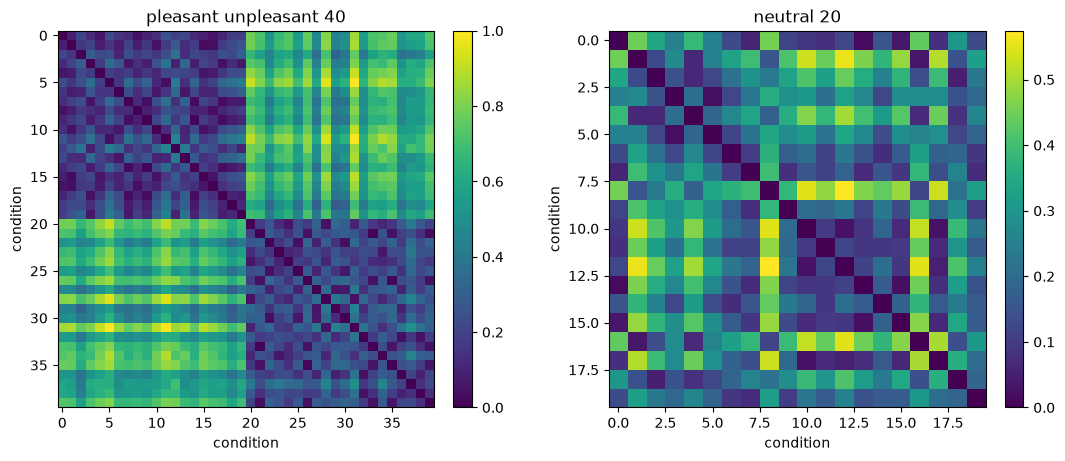

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for ax, (case_name, rdm) in zip(axes, CASE_RDMS.items()):
    image = ax.imshow(rdm, cmap="viridis")
    ax.set_title(case_name.replace("_", " "))
    ax.set_xlabel("condition")
    ax.set_ylabel("condition")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Define the radius-5 searchlight and reusable analysis functions

In [4]:
centers, neighbors = get_volume_searchlight(
    mask, radius=SEARCHLIGHT_RADIUS, threshold=MASK_THRESHOLD
)
centers = np.asarray(centers)
print(f"Searchlight centers: {len(centers):,}")
print(
    "Voxels per sphere (min/mean/max):",
    min(map(len, neighbors)),
    f"{np.mean(list(map(len, neighbors))):.1f}",
    max(map(len, neighbors)),
)

Finding searchlights...:   0%|          | 0/59159 [00:00<?, ?it/s]

Finding searchlights...:   1%|          | 348/59159 [00:00<00:16, 3473.28it/s]

Finding searchlights...:   1%|          | 696/59159 [00:00<00:17, 3355.01it/s]

Finding searchlights...:   2%|▏         | 1032/59159 [00:00<00:17, 3300.48it/s]

Finding searchlights...:   2%|▏         | 1461/59159 [00:00<00:15, 3639.77it/s]

Finding searchlights...:   3%|▎         | 1826/59159 [00:00<00:16, 3384.74it/s]

Finding searchlights...:   4%|▎         | 2168/59159 [00:00<00:17, 3314.13it/s]

Finding searchlights...:   4%|▍         | 2648/59159 [00:00<00:15, 3747.30it/s]

Finding searchlights...:   5%|▌         | 3026/59159 [00:00<00:15, 3664.17it/s]

Finding searchlights...:   6%|▌         | 3468/59159 [00:00<00:14, 3889.04it/s]

Finding searchlights...:   7%|▋         | 3977/59159 [00:01<00:13, 4235.19it/s]

Finding searchlights...:   7%|▋         | 4416/59159 [00:01<00:12, 4274.70it/s]

Finding searchlights...:   8%|▊         | 4926/59159 [00:01<00:12, 4511.60it/s]

Finding searchlights...:   9%|▉         | 5379/59159 [00:01<00:12, 4188.28it/s]

Finding searchlights...:  10%|▉         | 5881/59159 [00:01<00:12, 4400.60it/s]

Finding searchlights...:  11%|█         | 6335/59159 [00:01<00:11, 4440.43it/s]

Finding searchlights...:  12%|█▏        | 6884/59159 [00:01<00:11, 4721.47it/s]

Finding searchlights...:  12%|█▏        | 7362/59159 [00:01<00:11, 4598.55it/s]

Finding searchlights...:  13%|█▎        | 7825/59159 [00:02<00:20, 2507.84it/s]

Finding searchlights...:  14%|█▍        | 8253/59159 [00:02<00:17, 2832.31it/s]

Finding searchlights...:  15%|█▍        | 8785/59159 [00:02<00:15, 3336.54it/s]

Finding searchlights...:  16%|█▌        | 9252/59159 [00:02<00:13, 3637.18it/s]

Finding searchlights...:  16%|█▋        | 9688/59159 [00:02<00:13, 3643.72it/s]

Finding searchlights...:  17%|█▋        | 10129/59159 [00:02<00:12, 3824.77it/s]

Finding searchlights...:  18%|█▊        | 10661/59159 [00:02<00:11, 4201.65it/s]

Finding searchlights...:  19%|█▉        | 11113/59159 [00:02<00:11, 4173.13it/s]

Finding searchlights...:  20%|█▉        | 11634/59159 [00:03<00:10, 4453.71it/s]

Finding searchlights...:  21%|██        | 12165/59159 [00:03<00:10, 4669.15it/s]

Finding searchlights...:  21%|██▏       | 12648/59159 [00:03<00:09, 4704.16it/s]

Finding searchlights...:  22%|██▏       | 13129/59159 [00:03<00:09, 4710.50it/s]

Finding searchlights...:  23%|██▎       | 13676/59159 [00:03<00:09, 4917.21it/s]

Finding searchlights...:  24%|██▍       | 14173/59159 [00:03<00:09, 4810.60it/s]

Finding searchlights...:  25%|██▍       | 14659/59159 [00:03<00:09, 4718.91it/s]

Finding searchlights...:  26%|██▌       | 15134/59159 [00:03<00:09, 4693.01it/s]

Finding searchlights...:  26%|██▋       | 15606/59159 [00:03<00:09, 4692.66it/s]

Finding searchlights...:  27%|██▋       | 16077/59159 [00:03<00:09, 4364.37it/s]

Finding searchlights...:  28%|██▊       | 16764/59159 [00:04<00:08, 5060.15it/s]

Finding searchlights...:  29%|██▉       | 17279/59159 [00:04<00:08, 5033.06it/s]

Finding searchlights...:  30%|███       | 17789/59159 [00:04<00:08, 4994.48it/s]

Finding searchlights...:  31%|███       | 18317/59159 [00:04<00:08, 4997.65it/s]

Finding searchlights...:  32%|███▏      | 18820/59159 [00:04<00:08, 4955.10it/s]

Finding searchlights...:  33%|███▎      | 19318/59159 [00:04<00:08, 4739.24it/s]

Finding searchlights...:  33%|███▎      | 19795/59159 [00:04<00:08, 4539.30it/s]

Finding searchlights...:  34%|███▍      | 20315/59159 [00:04<00:08, 4711.08it/s]

Finding searchlights...:  35%|███▌      | 20852/59159 [00:04<00:07, 4882.03it/s]

Finding searchlights...:  36%|███▌      | 21404/59159 [00:05<00:07, 5062.20it/s]

Finding searchlights...:  37%|███▋      | 21914/59159 [00:05<00:07, 4837.66it/s]

Finding searchlights...:  38%|███▊      | 22402/59159 [00:05<00:07, 4773.31it/s]

Finding searchlights...:  39%|███▊      | 22882/59159 [00:05<00:08, 4313.02it/s]

Finding searchlights...:  39%|███▉      | 23323/59159 [00:05<00:08, 4335.40it/s]

Finding searchlights...:  40%|████      | 23904/59159 [00:05<00:07, 4733.08it/s]

Finding searchlights...:  41%|████▏     | 24443/59159 [00:05<00:07, 4918.87it/s]

Finding searchlights...:  42%|████▏     | 24942/59159 [00:05<00:07, 4573.67it/s]

Finding searchlights...:  43%|████▎     | 25453/59159 [00:05<00:07, 4710.99it/s]

Finding searchlights...:  44%|████▍     | 26006/59159 [00:06<00:06, 4925.87it/s]

Finding searchlights...:  45%|████▍     | 26505/59159 [00:06<00:06, 4897.35it/s]

Finding searchlights...:  46%|████▌     | 26999/59159 [00:06<00:06, 4682.93it/s]

Finding searchlights...:  47%|████▋     | 27738/59159 [00:06<00:05, 5442.90it/s]

Finding searchlights...:  48%|████▊     | 28327/59159 [00:06<00:05, 5564.53it/s]

Finding searchlights...:  49%|████▉     | 28890/59159 [00:06<00:05, 5128.54it/s]

Finding searchlights...:  50%|████▉     | 29515/59159 [00:06<00:05, 5426.47it/s]

Finding searchlights...:  51%|█████▏    | 30427/59159 [00:06<00:04, 6447.81it/s]

Finding searchlights...:  53%|█████▎    | 31084/59159 [00:07<00:10, 2650.17it/s]

Finding searchlights...:  54%|█████▎    | 31746/59159 [00:07<00:08, 3208.94it/s]

Finding searchlights...:  55%|█████▌    | 32566/59159 [00:07<00:06, 4055.16it/s]

Finding searchlights...:  56%|█████▌    | 33190/59159 [00:07<00:06, 4186.45it/s]

Finding searchlights...:  57%|█████▋    | 33764/59159 [00:07<00:05, 4372.70it/s]

Finding searchlights...:  58%|█████▊    | 34316/59159 [00:07<00:05, 4452.40it/s]

Finding searchlights...:  59%|█████▉    | 34890/59159 [00:08<00:05, 4712.99it/s]

Finding searchlights...:  60%|█████▉    | 35425/59159 [00:08<00:05, 4476.93it/s]

Finding searchlights...:  61%|██████    | 35918/59159 [00:08<00:05, 4533.39it/s]

Finding searchlights...:  62%|██████▏   | 36404/59159 [00:08<00:04, 4608.59it/s]

Finding searchlights...:  62%|██████▏   | 36900/59159 [00:08<00:04, 4695.72it/s]

Finding searchlights...:  63%|██████▎   | 37388/59159 [00:08<00:04, 4664.04it/s]

Finding searchlights...:  64%|██████▍   | 37867/59159 [00:08<00:04, 4324.51it/s]

Finding searchlights...:  65%|██████▍   | 38317/59159 [00:08<00:04, 4355.15it/s]

Finding searchlights...:  66%|██████▌   | 38826/59159 [00:08<00:04, 4557.65it/s]

Finding searchlights...:  66%|██████▋   | 39290/59159 [00:09<00:04, 4552.04it/s]

Finding searchlights...:  67%|██████▋   | 39751/59159 [00:09<00:04, 4298.76it/s]

Finding searchlights...:  68%|██████▊   | 40267/59159 [00:09<00:04, 4519.79it/s]

Finding searchlights...:  69%|██████▉   | 40872/59159 [00:09<00:03, 4948.37it/s]

Finding searchlights...:  70%|██████▉   | 41374/59159 [00:09<00:03, 4751.34it/s]

Finding searchlights...:  71%|███████   | 41855/59159 [00:09<00:03, 4731.36it/s]

Finding searchlights...:  72%|███████▏  | 42382/59159 [00:09<00:03, 4878.09it/s]

Finding searchlights...:  73%|███████▎  | 42914/59159 [00:09<00:03, 4978.17it/s]

Finding searchlights...:  73%|███████▎  | 43450/59159 [00:09<00:03, 5082.46it/s]

Finding searchlights...:  74%|███████▍  | 43961/59159 [00:10<00:03, 4665.19it/s]

Finding searchlights...:  75%|███████▌  | 44480/59159 [00:10<00:03, 4794.55it/s]

Finding searchlights...:  76%|███████▌  | 45042/59159 [00:10<00:02, 4999.87it/s]

Finding searchlights...:  77%|███████▋  | 45548/59159 [00:10<00:02, 4960.42it/s]

Finding searchlights...:  78%|███████▊  | 46048/59159 [00:10<00:02, 4892.20it/s]

Finding searchlights...:  79%|███████▉  | 46776/59159 [00:10<00:02, 5569.60it/s]

Finding searchlights...:  80%|████████  | 47343/59159 [00:10<00:02, 5576.59it/s]

Finding searchlights...:  81%|████████  | 47904/59159 [00:10<00:02, 5110.86it/s]

Finding searchlights...:  82%|████████▏ | 48425/59159 [00:10<00:02, 4944.98it/s]

Finding searchlights...:  83%|████████▎ | 48985/59159 [00:10<00:01, 5112.40it/s]

Finding searchlights...:  84%|████████▎ | 49503/59159 [00:11<00:01, 4938.50it/s]

Finding searchlights...:  85%|████████▍ | 50002/59159 [00:11<00:01, 4894.52it/s]

Finding searchlights...:  85%|████████▌ | 50495/59159 [00:11<00:01, 4683.27it/s]

Finding searchlights...:  87%|████████▋ | 51233/59159 [00:11<00:01, 5351.34it/s]

Finding searchlights...:  88%|████████▊ | 51830/59159 [00:11<00:01, 5479.31it/s]

Finding searchlights...:  89%|████████▊ | 52382/59159 [00:11<00:01, 5185.12it/s]

Finding searchlights...:  89%|████████▉ | 52906/59159 [00:11<00:01, 5163.85it/s]

Finding searchlights...:  90%|█████████ | 53485/59159 [00:11<00:01, 5334.43it/s]

Finding searchlights...:  92%|█████████▏| 54163/59159 [00:11<00:00, 5740.48it/s]

Finding searchlights...:  93%|█████████▎| 54741/59159 [00:12<00:00, 4919.17it/s]

Finding searchlights...:  93%|█████████▎| 55256/59159 [00:12<00:00, 4913.91it/s]

Finding searchlights...:  94%|█████████▍| 55763/59159 [00:12<00:00, 4724.67it/s]

Finding searchlights...:  95%|█████████▌| 56251/59159 [00:12<00:00, 4749.88it/s]

Finding searchlights...:  96%|█████████▌| 56735/59159 [00:12<00:00, 4425.09it/s]

Finding searchlights...:  97%|█████████▋| 57187/59159 [00:13<00:01, 1629.81it/s]

Finding searchlights...:  98%|█████████▊| 57847/59159 [00:13<00:00, 2235.75it/s]

Finding searchlights...:  99%|█████████▉| 58458/59159 [00:13<00:00, 2808.27it/s]

Finding searchlights...: 100%|█████████▉| 59005/59159 [00:13<00:00, 3267.68it/s]

Finding searchlights...: 100%|██████████| 59159/59159 [00:13<00:00, 4340.77it/s]

Found 56949 searchlights


Searchlight centers: 56,949
Voxels per sphere (min/mean/max): 277 483.8 485


In [5]:
def upper_tri(rdm):
    rows, cols = np.triu_indices(rdm.shape[0], k=1)
    return rdm[rows, cols]


def evaluate_case(case_name, condition_indices, model_rdm):
    # Run or resume subject-level searchlight RSA for one condition subset.
    condition_indices = np.asarray(condition_indices)
    model = ModelFixed(case_name, upper_tri(model_rdm))
    expected_center_ids = None
    subject_scores = []

    for subject_index in tqdm(range(N_SUBJECTS), desc=case_name):
        cache_path = SCORE_DIR / f"{case_name}_sub-{subject_index + 1:02d}_scores.npy"

        if cache_path.exists() and not FORCE_RECOMPUTE:
            scores = np.load(cache_path)
            if scores.shape != (len(centers),):
                raise ValueError(
                    f"Cached score shape mismatch in {cache_path}: {scores.shape}"
                )
        else:
            # Load only this subject and this condition subset into memory.
            subject_data = np.nan_to_num(
                np.asarray(allsub_avg[subject_index, condition_indices, :]),
                copy=False,
            )
            image_values = np.arange(len(condition_indices))
            searchlight_rdms = get_searchlight_RDMs(
                subject_data,
                centers,
                neighbors,
                image_values,
                method="correlation",
            )
            evaluation_results = evaluate_models_searchlight(
                searchlight_rdms,
                model,
                eval_fixed,
                method="spearman",
                n_jobs=N_JOBS,
            )
            scores = np.asarray(
                [float(np.asarray(result.evaluations).squeeze()) for result in evaluation_results],
                dtype=np.float32,
            )
            np.save(cache_path, scores)

        subject_scores.append(scores)

        # get_volume_searchlight centers are the voxel IDs used by the RDMs.
        # Keeping this check here protects against cache/configuration mismatch.
        center_ids = centers.astype(int, copy=False)
        if expected_center_ids is None:
            expected_center_ids = center_ids
        elif not np.array_equal(center_ids, expected_center_ids):
            raise RuntimeError("Searchlight center IDs changed between subjects.")

    subject_scores = np.vstack(subject_scores)
    np.save(SCORE_DIR / f"{case_name}_20sub_scores.npy", subject_scores)
    np.save(SCORE_DIR / f"{case_name}_voxel_center_ids.npy", expected_center_ids)
    return subject_scores, expected_center_ids


def second_level_fdr_tmap(subject_scores, center_ids, output_name):
    # Fisher-z, one-sample t-test, BH-FDR, and signed significant-t NIfTI.
    eps = np.finfo(np.float64).eps
    correlations = np.clip(subject_scores.astype(float), -1 + eps, 1 - eps)
    fisher_z = np.arctanh(correlations)
    t_values, p_values = ttest_1samp(fisher_z, popmean=0, axis=0, nan_policy="omit")

    reject = np.zeros(p_values.shape, dtype=bool)
    corrected_p = np.full(p_values.shape, np.nan, dtype=float)
    finite = np.isfinite(p_values)
    reject_finite, corrected_finite = fdrcorrection(
        p_values[finite], alpha=FDR_ALPHA, method="indep", is_sorted=False
    )
    reject[finite] = reject_finite
    corrected_p[finite] = corrected_finite

    map_flat = np.zeros(mask.size, dtype=np.float32)
    significant = reject & np.isfinite(t_values)
    map_flat[np.asarray(center_ids, dtype=int)[significant]] = t_values[significant]
    map_img = new_img_like(template_img, map_flat.reshape(mask.shape), copy_header=True)
    output_path = MAP_DIR / output_name
    nib.save(map_img, output_path)

    return {
        "output": str(output_path),
        "n_centers_tested": int(finite.sum()),
        "n_fdr_significant": int(significant.sum()),
        "n_positive": int(np.sum(significant & (t_values > 0))),
        "n_negative": int(np.sum(significant & (t_values < 0))),
        "min_fdr_p": float(np.nanmin(corrected_p)),
    }

## Run the two subject-level cases

This is the long-running section. Per-subject caches allow the cell to resume after interruption.

In [6]:
case_scores = {}
case_center_ids = {}

for case_name, indices in CASE_INDICES.items():
    scores, center_ids = evaluate_case(case_name, indices, CASE_RDMS[case_name])
    case_scores[case_name] = scores
    case_center_ids[case_name] = center_ids
    print(case_name, "score matrix:", scores.shape)

pleasant_unpleasant_40:   0%|          | 0/20 [00:00<?, ?it/s]

pleasant_unpleasant_40:  10%|█         | 2/20 [00:00<00:01, 15.42it/s]

pleasant_unpleasant_40:  20%|██        | 4/20 [00:00<00:00, 17.10it/s]

pleasant_unpleasant_40:  30%|███       | 6/20 [00:00<00:00, 16.65it/s]

pleasant_unpleasant_40:  40%|████      | 8/20 [00:00<00:00, 16.93it/s]

pleasant_unpleasant_40:  50%|█████     | 10/20 [00:00<00:00, 16.02it/s]

pleasant_unpleasant_40:  60%|██████    | 12/20 [00:00<00:00, 16.52it/s]

pleasant_unpleasant_40:  70%|███████   | 14/20 [00:00<00:00, 16.43it/s]

pleasant_unpleasant_40:  80%|████████  | 16/20 [00:01<00:00, 13.80it/s]

pleasant_unpleasant_40:  90%|█████████ | 18/20 [00:01<00:00, 13.35it/s]

pleasant_unpleasant_40: 100%|██████████| 20/20 [00:01<00:00, 14.00it/s]

pleasant_unpleasant_40: 100%|██████████| 20/20 [00:01<00:00, 15.01it/s]

pleasant_unpleasant_40 score matrix: (20, 56949)


neutral_20:   0%|          | 0/20 [00:00<?, ?it/s]

neutral_20:  10%|█         | 2/20 [00:00<00:01, 16.22it/s]

neutral_20:  20%|██        | 4/20 [00:00<00:00, 18.09it/s]

neutral_20:  30%|███       | 6/20 [00:00<00:00, 15.90it/s]

neutral_20:  40%|████      | 8/20 [00:00<00:00, 16.21it/s]

neutral_20:  50%|█████     | 10/20 [00:00<00:00, 16.27it/s]

neutral_20:  60%|██████    | 12/20 [00:00<00:00, 17.11it/s]

neutral_20:  70%|███████   | 14/20 [00:00<00:00, 15.73it/s]

neutral_20:  80%|████████  | 16/20 [00:00<00:00, 15.47it/s]

neutral_20:  90%|█████████ | 18/20 [00:01<00:00, 16.50it/s]

neutral_20: 100%|██████████| 20/20 [00:01<00:00, 16.52it/s]

neutral_20: 100%|██████████| 20/20 [00:01<00:00, 16.37it/s]

neutral_20 score matrix: (20, 56949)


## Second-level FDR correction and final NIfTI outputs

In [7]:
output_names = {
    "pleasant_unpleasant_40": "tmap_beh40_pleasant_unpleasant_fisherz_fdr05.nii.gz",
    "neutral_20": "tmap_beh20_neutral_fisherz_fdr05.nii.gz",
}

summaries = []
for case_name in CASE_INDICES:
    summary = second_level_fdr_tmap(
        case_scores[case_name],
        case_center_ids[case_name],
        output_names[case_name],
    )
    summaries.append({"case": case_name, **summary})

summary_table = pd.DataFrame(summaries)
display(summary_table)

for output_path in summary_table["output"]:
    assert Path(output_path).exists(), f"Output was not created: {output_path}"
    img = nib.load(output_path)
    assert img.shape == mask.shape, f"Unexpected NIfTI shape: {img.shape}"
    print(output_path)

,case,output,n_centers_tested,n_fdr_significant,n_positive,n_negative,min_fdr_p
0,pleasant_unpleasant_40,\\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yu...,56949,26652,26636,16,0.000024
1,neutral_20,\\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yu...,56949,0,0,0,0.062725


\\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap\SS\tmap_beh40_pleasant_unpleasant_fisherz_fdr05.nii.gz
\\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap\SS\tmap_beh20_neutral_fisherz_fdr05.nii.gz


pleasant_unpleasant_40



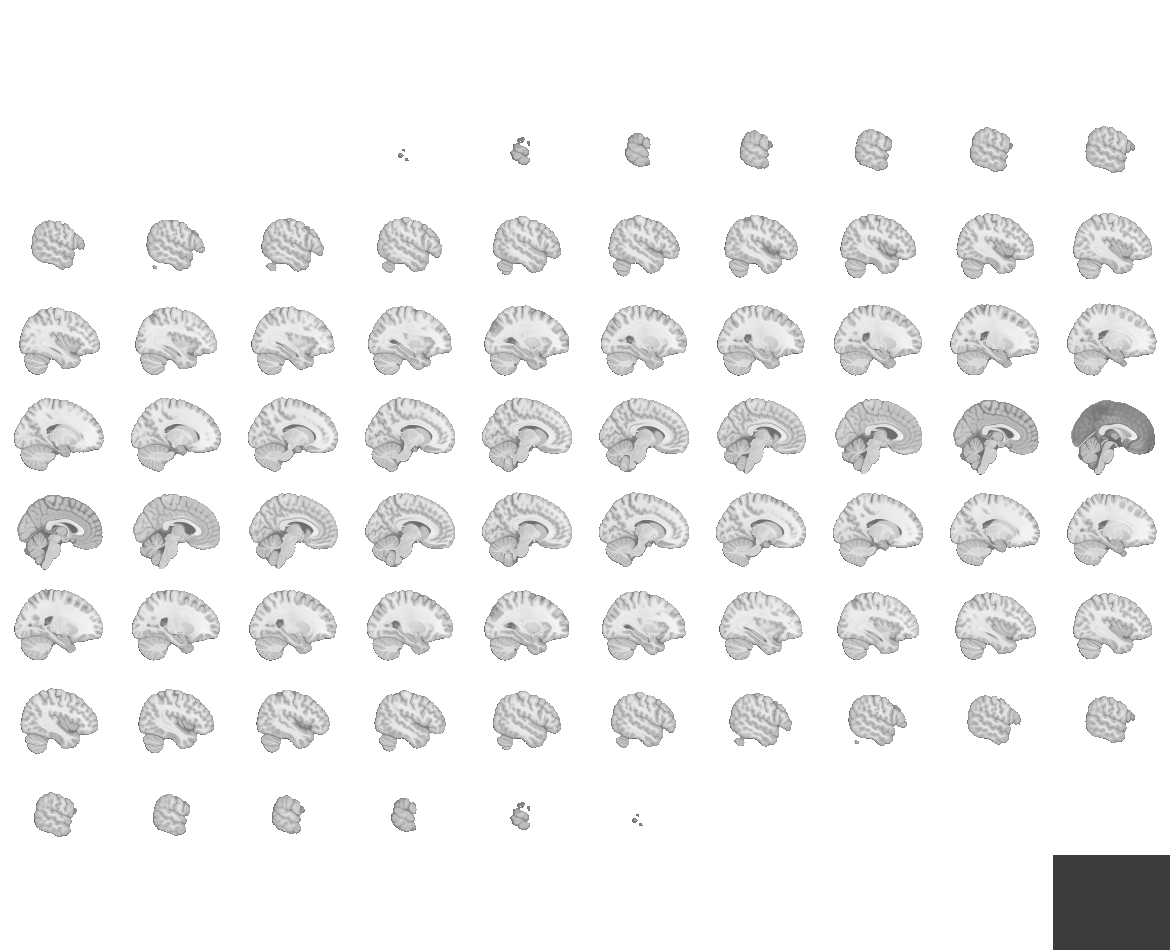
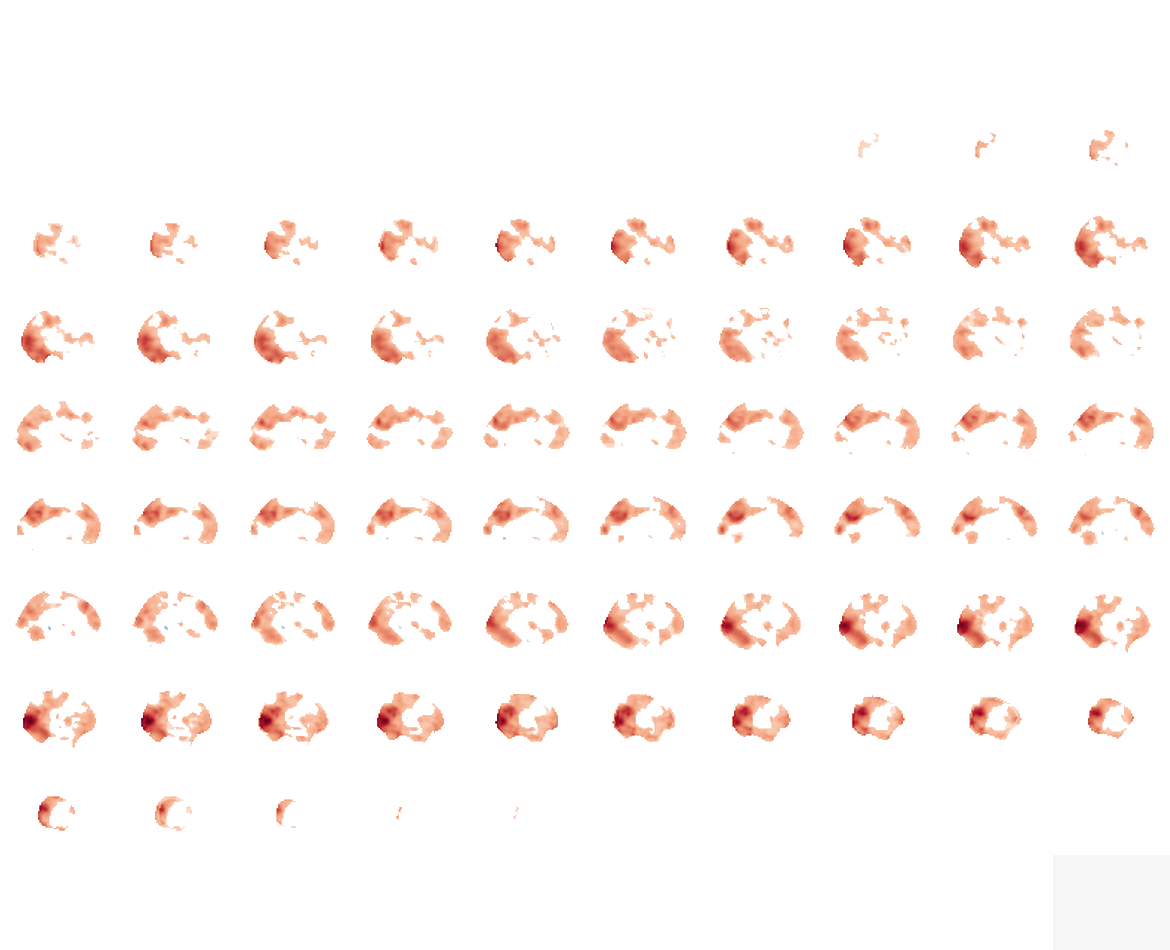

neutral_20


C:\Users\simona.sartan\AppData\Local\Temp\ipykernel_7724\2108539131.py:4: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  plotting.view_img(
C:\Users\simona.sartan\AppData\Local\Temp\ipykernel_7724\2108539131.py:4: UserWarning: Given img is empty. Returning default cut_coords=(0.0, 0.0, 0.0) instead.
  plotting.view_img(



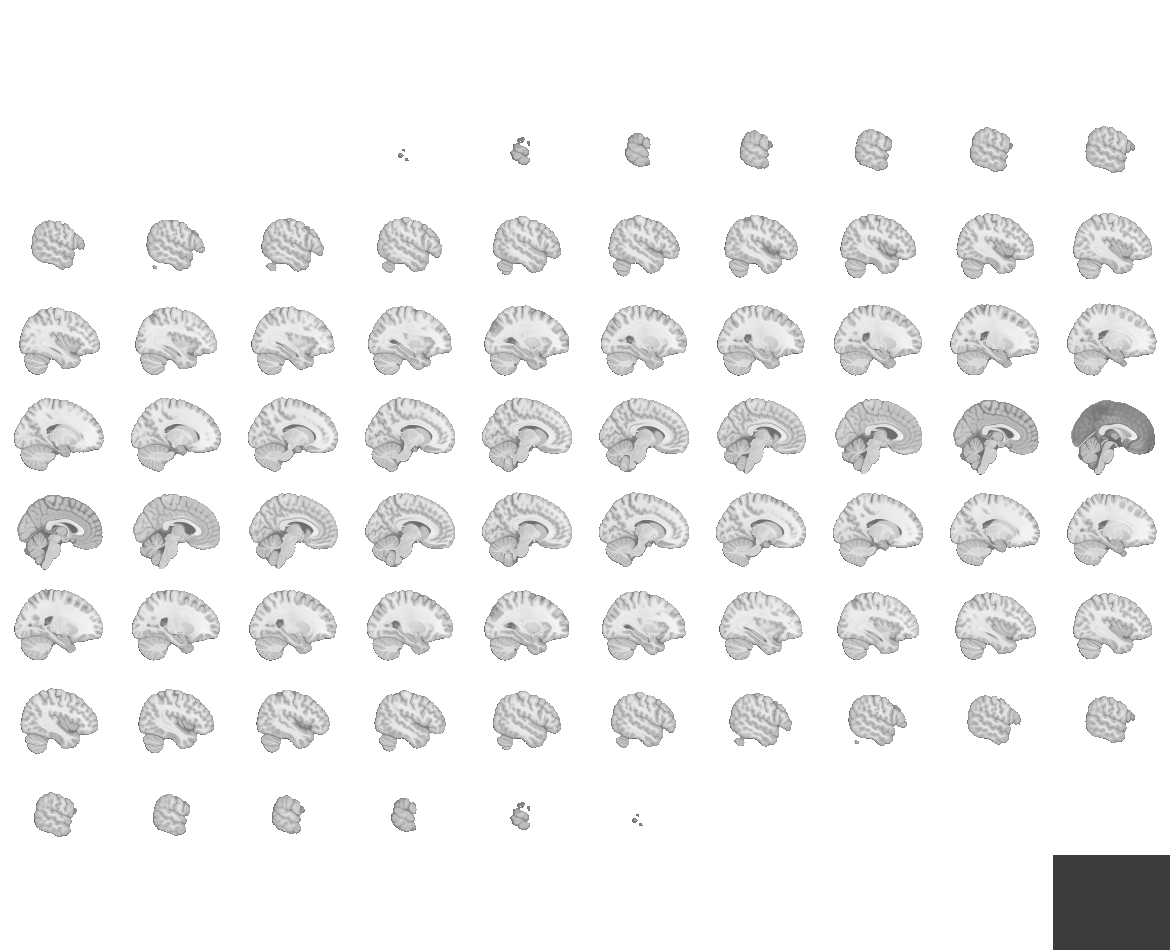
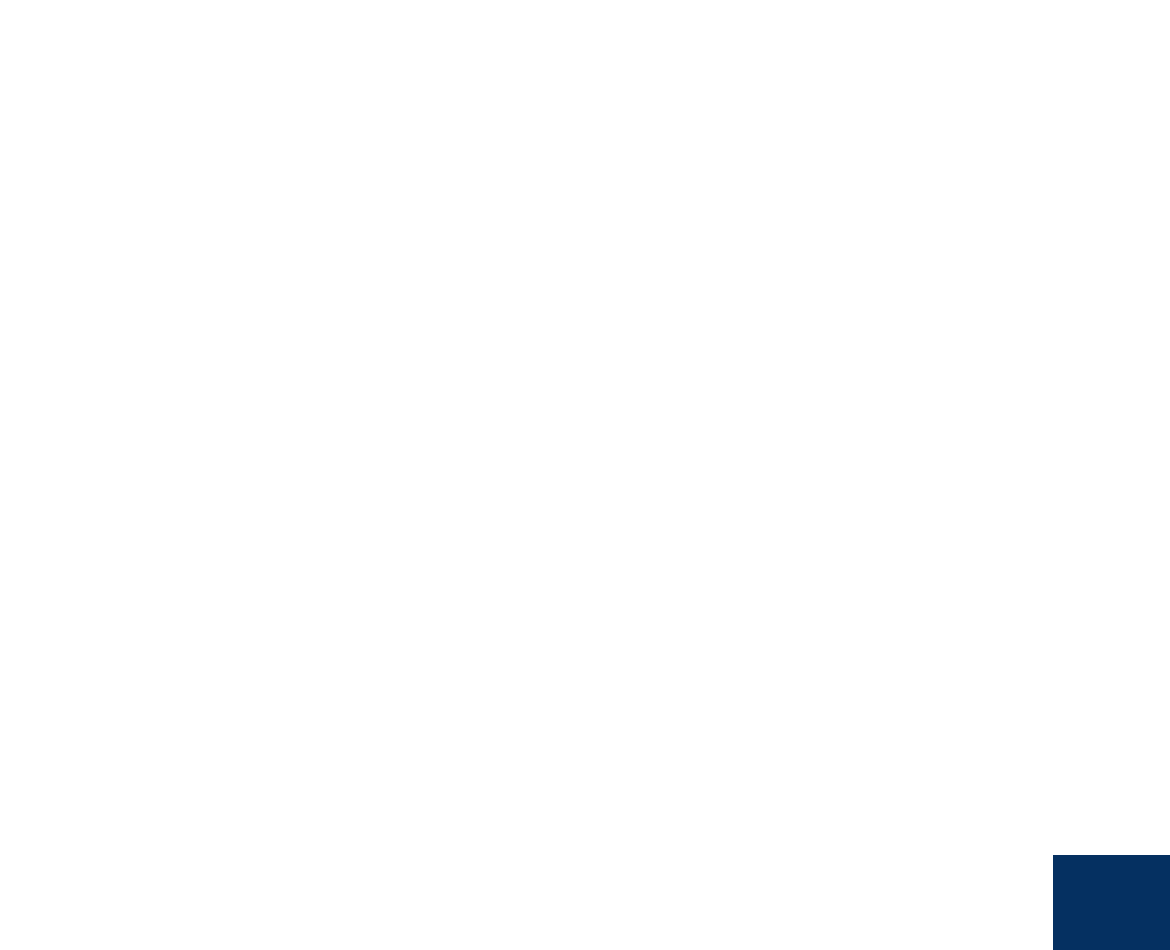

In [8]:
for row in summaries:
    print(row["case"])
    display(
        plotting.view_img(
            nib.load(row["output"]),
            draw_cross=False,
            black_bg=False,
            threshold=0,
            title=f"{row['case']} — signed FDR-significant t-values",
        )
    )